In [3]:
# Chunk 0 — Import & Load (updated for more models)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    silhouette_score,
)

from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.linear_model import LogisticRegression

# 尝试导入 XGBoost
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

# 尝试导入 CatBoost
try:
    from CatBoost import CatBoostClassifier  # 如果报错，再用小写 catboost
    CATBOOST_OK = True
except Exception:
    try:
        from catboost import CatBoostClassifier
        CATBOOST_OK = True
    except Exception:
        CATBOOST_OK = False

# 尝试导入 LightGBM
try:
    from lightgbm import LGBMClassifier
    LGBM_OK = True
except Exception:
    LGBM_OK = False

plt.style.use("default")
sns.set_theme()

# 读取数据
file_path = "train_advance.csv"
df_raw = pd.read_csv(file_path)

print("[INFO] Loaded shape:", df_raw.shape)
print("[INFO] Columns:", list(df_raw.columns))
df_raw.head()


[INFO] Loaded shape: (22924, 31)
[INFO] Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'location_id', 'profile_id', 'sid', 'sid_profile', 'post_id', 'post_type', 'description', 'numbr_likes', 'number_comments', 'profile_name', 'firstname_lastname', 'following', 'followers', 'n_posts', 'url', 'is_business_account', 'name', 'zip', 'city', 'region', 'cd', 'phone', 'aj_exact_city_match', 'aj_exact_country_match', 'blurb', 'dir_city_name', 'dir_country_name', 'lat', 'lng']


,Unnamed: 0.1,Unnamed: 0,location_id,profile_id,sid,sid_profile,post_id,post_type,description,numbr_likes,...,region,cd,phone,aj_exact_city_match,aj_exact_country_match,blurb,dir_city_name,dir_country_name,lat,lng
0,11420,11755,340283947,829324748,28919418,295070,Bka_6xunYma,1,Cheers to wine O‚Äôclock ü•Ç (üì∏: @aob1085),4985,...,NaN,ES,+34 936 65 77 41,False,False,NaN,El Prat de Llobregat,Spain,2,41
1,24264,24967,2631322,199074048,42114489,4342099,BxaZS4fA_nV,1,#malcapuyaisland #bananaisland #bulogisland,57,...,NaN,PH,NaN,True,False,NaN,Coron,Philippines,120,11
2,16286,16768,668571209,3280121227,19193237,2554203,BxmEzQUFocM,1,üî∏\\nSchwarzkehlchen (Saxicola rubicola) ‚Ä¢...,1576,...,Saxony-Anhalt,DE,NaN,False,True,NaN,NaN,NaN,11,51
3,11139,11467,238461670,5625643374,11733129,3465973,Bjq5KFGlJvM,1,Eared Grebe spotted at one of my favourite spo...,29,...,NaN,CA,NaN,True,False,NaN,NaN,NaN,-118,52
4,27320,28111,1005642734,1557071010,8540244,3541402,BweviowATmj,1,–ü–õ–ê–ö–ê–¢–¨ –í –ú–û–°–¢–ê–• - –≠–¢–û –ù–û–†...,1487,...,NaN,RU,79214201362,False,False,—Ü–µ–Ω—Ç—Ä –∏–Ω–∏—Ü–∏–∞—Ü–∏–∏ —Ç–≤–æ—Ä—á–µ—Å—Ç...,Aptekarskiy,Russia,30,59


In [4]:
# ===============================================
# Chunk 0 — Load train_advance / test_advance
# ===============================================

import pandas as pd
import numpy as np

print("[0] ===== Load Instagram Likes Prediction Dataset =====")

train_path = "train_advance.csv"
test_path  = "test_advance.csv"

df_train_raw = pd.read_csv(train_path)
df_test_raw  = pd.read_csv(test_path)

print(f"[0] Train shape: {df_train_raw.shape}")
print(f"[0] Test shape:  {df_test_raw.shape}")

print("[0] Train columns:", df_train_raw.columns.tolist())

# Mark train/test
df_train_raw["__is_train"] = 1
df_test_raw["__is_train"] = 0

# Combine for unified cleaning
df_all = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

# =========================
# Basic Cleaning
# =========================

# Remove useless index columns
drop_cols = [c for c in df_all.columns if "Unnamed" in c]
df_all = df_all.drop(columns=drop_cols)

# Ensure description is string
df_all["description"] = df_all["description"].fillna("").astype(str)

# Fix numeric columns
numeric_cols = ["numbr_likes", "number_comments", "following", "followers", "n_posts", "lat", "lng"]
for col in numeric_cols:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

# Fill numeric NaNs with 0
df_all[numeric_cols] = df_all[numeric_cols].fillna(0)

# Convert business flag
if "is_business_account" in df_all.columns:
    df_all["is_business_account"] = df_all["is_business_account"].astype(str)

print("[0] After cleaning:", df_all.shape)
print("[0] Done with Chunk 0.")

[0] ===== Load Instagram Likes Prediction Dataset =====
[0] Train shape: (22924, 31)
[0] Test shape:  (5731, 32)
[0] Train columns: ['Unnamed: 0.1', 'Unnamed: 0', 'location_id', 'profile_id', 'sid', 'sid_profile', 'post_id', 'post_type', 'description', 'numbr_likes', 'number_comments', 'profile_name', 'firstname_lastname', 'following', 'followers', 'n_posts', 'url', 'is_business_account', 'name', 'zip', 'city', 'region', 'cd', 'phone', 'aj_exact_city_match', 'aj_exact_country_match', 'blurb', 'dir_city_name', 'dir_country_name', 'lat', 'lng']
[0] After cleaning: (28655, 30)
[0] Done with Chunk 0.


In [5]:
"""
Chunk 0 — Load Dataset
Goal:
- Load train_advance.csv
- Drop duplicated index columns
- Standardize column names
"""

import pandas as pd
import numpy as np

df = pd.read_csv("train_advance.csv")

print("[0] Raw shape:", df.shape)

# Remove useless duplicate index columns
drop_cols = [c for c in df.columns if "Unnamed" in c]
df = df.drop(columns=drop_cols)

df.columns = df.columns.str.strip()
print("[0] Cleaned cols:", df.columns.tolist())
print("[0] New shape:", df.shape)

[0] Raw shape: (22924, 31)
[0] Cleaned cols: ['location_id', 'profile_id', 'sid', 'sid_profile', 'post_id', 'post_type', 'description', 'numbr_likes', 'number_comments', 'profile_name', 'firstname_lastname', 'following', 'followers', 'n_posts', 'url', 'is_business_account', 'name', 'zip', 'city', 'region', 'cd', 'phone', 'aj_exact_city_match', 'aj_exact_country_match', 'blurb', 'dir_city_name', 'dir_country_name', 'lat', 'lng']
[0] New shape: (22924, 29)


In [6]:
"""
Chunk 1 — Select SAFE features for pre-launch prediction

We CANNOT use:
- numbr_likes     → label
- number_comments → leakage
- any post-engagement info

We only keep safe, pre-launch info.
"""

safe_features = [
    "post_type",
    "description",
    "following",
    "followers",
    "n_posts",
    "is_business_account",
    "city",
    "cd",
]

existing = [c for c in safe_features if c in df.columns]
X = df[existing].copy()

y = df["numbr_likes"].copy()   # still regression target for next chunk

print("[1] Using SAFE features:", existing)
print("[1] X shape:", X.shape)

[1] Using SAFE features: ['post_type', 'description', 'following', 'followers', 'n_posts', 'is_business_account', 'city', 'cd']
[1] X shape: (22924, 8)


In [37]:
"""
Chunk 2 — Create viral_label from ER

ER = likes / (followers + 1)
Using log1p to stabilize extreme values.
"""

df["ER"] = df["numbr_likes"] / (df["followers"] + 1)
df["log_ER"] = np.log1p(df["ER"])

thr = df["log_ER"].quantile(0.90)
df["viral_label"] = (df["log_ER"] >= thr).astype(int)

print("[2] Viral threshold (log_ER):", thr)
print(df["viral_label"].value_counts())

[2] Viral threshold (log_ER): 0.19944157936232318
viral_label
0    20631
1     2293
Name: count, dtype: int64


In [38]:
"""
Chunk 3 — Text Feature Engineering
Goal: Convert description into numeric pre-launch features.
"""

import re

def count_hashtags(x):
    if pd.isna(x):
        return 0
    return x.count("#")

def desc_length(x):
    if pd.isna(x):
        return 0
    return len(str(x))

X["desc_length"] = X["description"].fillna("").apply(desc_length)
X["hashtag_count"] = X["description"].fillna("").apply(count_hashtags)

X = X.drop(columns=["description"], errors="ignore")

print("[3] Added text features. X:", X.shape)

KeyError: 'description'

In [39]:
"""
Chunk 4 — Clean & Encode
- Fill missing values
- Convert categorical features to strings
"""
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Identify column types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

print("[4] Categorical:", cat_cols)
print("[4] Numeric:", num_cols)

# Fill missing
for c in num_cols:
    X[c] = X[c].fillna(X[c].median())

for c in cat_cols:
    X[c] = X[c].astype(str).fillna("missing")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, df["viral_label"], test_size=0.25, random_state=42, stratify=df["viral_label"]
)

print("[4] Train:", X_train.shape, "| Test:", X_test.shape)

preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

[4] Categorical: ['following', 'is_business_account', 'city', 'cd']
[4] Numeric: ['post_type', 'followers', 'n_posts', 'desc_length', 'hashtag_count']
[4] Train: (17193, 9) | Test: (5731, 9)


In [10]:
"""
Chunk 5 — Baseline Models
Try: Logistic Regression + RandomForest
"""
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

models = {
    "Logistic": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight={0:1, 1:3},
        n_jobs=-1,
    )
}

for name, clf in models.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, digits=4))


===== Logistic =====
              precision    recall  f1-score   support

           0     0.9435    0.8057    0.8692      5158
           1     0.2443    0.5654    0.3412       573

    accuracy                         0.7817      5731
   macro avg     0.5939    0.6856    0.6052      5731
weighted avg     0.8736    0.7817    0.8164      5731


===== RandomForest =====
              precision    recall  f1-score   support

           0     0.9000    1.0000    0.9474      5158
           1     0.0000    0.0000    0.0000       573

    accuracy                         0.9000      5731
   macro avg     0.4500    0.5000    0.4737      5731
weighted avg     0.8100    0.9000    0.8527      5731



/opt/anaconda3/envs/viralpost/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/viralpost/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/viralpost/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [11]:
"""
Chunk 6 — L1/L2 regularized logistic
"""

models_reg = {
    "L1_Lasso": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
    ),
    "L2_Ridge": LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
    ),
}

for name, clf in models_reg.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, digits=4))


===== L1_Lasso =====
              precision    recall  f1-score   support

           0     0.9573    0.8129    0.8792      5158
           1     0.2857    0.6736    0.4012       573

    accuracy                         0.7990      5731
   macro avg     0.6215    0.7433    0.6402      5731
weighted avg     0.8902    0.7990    0.8314      5731


===== L2_Ridge =====
              precision    recall  f1-score   support

           0     0.9435    0.8057    0.8692      5158
           1     0.2443    0.5654    0.3412       573

    accuracy                         0.7817      5731
   macro avg     0.5939    0.6856    0.6052      5731
weighted avg     0.8736    0.7817    0.8164      5731



In [12]:
"""
Chunk 7 — XGBoost / LightGBM / CatBoost if available
"""

try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
    )
    pipe = Pipeline([("pre", preprocessor), ("clf", xgb)])
    pipe.fit(X_train, y_train)
    print("\n===== XGBoost =====")
    print(classification_report(y_test, pipe.predict(X_test), digits=4))
except:
    print("XGB not installed")


===== XGBoost =====
              precision    recall  f1-score   support

           0     0.9766    0.8019    0.8807      5158
           1     0.3168    0.8272    0.4582       573

    accuracy                         0.8044      5731
   macro avg     0.6467    0.8145    0.6694      5731
weighted avg     0.9107    0.8044    0.8384      5731



EDA

In [26]:
# 处理语言
!pip install ftfy
from ftfy import fix_text

print("[T0] ===== Unicode Fixing =====")

df["description_clean"] = (
    df["description"]
    .fillna("")
    .apply(fix_text)
)

print(df["description_clean"].head(10))
print("[T0] Done.\n")

[T0] ===== Unicode Fixing =====
0               Cheers to wine O'clock 🥂 (📸: @aob1085)
1          #malcapuyaisland #bananaisland #bulogisland
2    🔸\\nSchwarzkehlchen (Saxicola rubicola) •❥❥❧❥❥...
3    Eared Grebe spotted at one of my favourite spo...
4    ПЛАКАТЬ В МОСТАХ - ЭТО НОРМАЛЬНО, ЭТО КАК ПОТЕ...
5    Be charitable and indulgent to everyone but yo...
6                                       Serenity 🧘🏻‍♀️
7    –ë–ª–µ—Ç, –≤ –∏–Ω—Å—Ç–µ —É–¥–∞–ª–∏–ª–∏ —Ñ–æ—Ç–...
8    Jak wasze popołudnie kochani?\\nNasze bardzo l...
9    JA Studios \nNew York City \nSoHo \nLive Perfo...
Name: description_clean, dtype: object
[T0] Done.



In [27]:
!pip install langdetect
from langdetect import detect, LangDetectException

print("[T1] ===== Language Detection =====")

def detect_lang(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["lang"] = df["description_clean"].apply(detect_lang)

# 合并 rare 语言
df["lang"] = df["lang"].apply(lambda x: x if x in ["en", "es", "fr", "de", "it", "ko", "zh-cn", "zh-tw"] else "other")

print(df["lang"].value_counts())
print("[T1] Done.\n")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 6.5 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993332 sha256=3e934d71865386c20e81f43d7e052335a2362f9a735ef9c583ac03a3f9072998
  Stored in directory: /Users/meihui/Library/Caches/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect
[T1] ===== Language Detection =====
lang
en       12381
other     8494
es         782
it         507
fr         332
de         330
ko          86
zh-cn        7
zh-tw        5
Name: count, dtype: int64
[T1] Done.



In [29]:
import re

!pip install emoji
import emoji

print("[T2] ===== Text Normalization =====")

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # remove emojis
    text = emoji.replace_emoji(text, replace="")

    # convert hashtags → keep word (#cute → cute)
    text = re.sub(r"#(\w+)", r"\1", text)

    # remove @mentions
    text = re.sub(r"@\w+", " ", text)

    # remove non-alphabetic chars
    text = re.sub(r"[^a-z\s]", " ", text)

    # collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text_clean_norm"] = df["description_clean"].apply(clean_text)

print(df[["description", "text_clean_norm"]].head())
print("[T2] Done.\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.6 MB/s  0:00:00
[T2] ===== Text Normalization =====
                                         description  \
0     Cheers to wine O‚Äôclock ü•Ç (üì∏: @aob1085)   
1        #malcapuyaisland #bananaisland #bulogisland   
2  üî∏\\nSchwarzkehlchen (Saxicola rubicola) ‚Ä¢...   
3  Eared Grebe spotted at one of my favourite spo...   
4  –ü–õ–ê–ö–ê–¢–¨ –í –ú–û–°–¢–ê–• - –≠–¢–û –ù–û–†...   

                                     text_clean_norm  
0                             cheers to wine o clock  
1           malcapuyaisland bananaisland bulogisland  
2  nschwarzkehlchen saxicola rubicola n nwenn sie...  
3  eared grebe spotted at one of my favourite spo...  
4        n n n n n n n n n n n n n n n n humandesign  
[T2] Done.



In [30]:
print("[T3] ===== Auxiliary Text Features =====")

df["desc_len"] = df["description_clean"].apply(len)
df["word_count"] = df["description_clean"].apply(lambda x: len(x.split()))
df["hashtag_count"] = df["description_clean"].apply(lambda x: x.count("#"))
df["emoji_count"] = df["description_clean"].apply(lambda x: emoji.emoji_count(x))

print(df[["desc_len", "word_count", "hashtag_count", "emoji_count"]].head())
print("[T3] Done.\n")

[T3] ===== Auxiliary Text Features =====
   desc_len  word_count  hashtag_count  emoji_count
0        38           7              0            2
1        43           3              3            0
2      1340          86             26           51
3       134          15              4            0
4      1997         309              6            0
[T3] Done.



In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("[T4] ===== TF-IDF Vectorization (English Only) =====")

df["tfidf_text"] = df.apply(
    lambda row: row["text_clean_norm"] if row["lang"] == "en" else "",
    axis=1
)

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(df["tfidf_text"])

print(tfidf_matrix.shape)
print("[T4] Done.\n")

[T4] ===== TF-IDF Vectorization (English Only) =====
(22924, 5000)
[T4] Done.



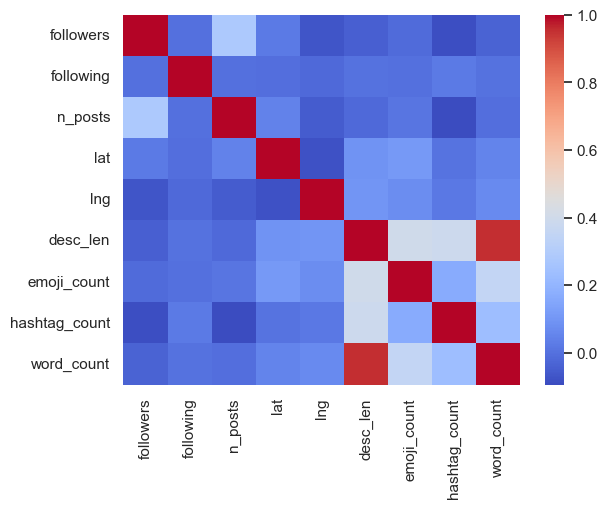

In [36]:
num_cols = [
    "followers", 
    "following", 
    "n_posts",
    "lat", "lng",
    "desc_len",
    "emoji_count",
    "hashtag_count",
    "word_count"
]

# Convert following → numeric
df["following"] = pd.to_numeric(df["following"], errors="coerce")

# Select numeric subset
num_df = df[num_cols]

sns.heatmap(num_df.corr(), annot=False, cmap="coolwarm")
plt.show()

In [13]:
import pandas as pd
import numpy as np

print("Shape:", df.shape)
df.info()
df.head()

Shape: (22924, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22924 entries, 0 to 22923
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   location_id             22924 non-null  int64  
 1   profile_id              22924 non-null  int64  
 2   sid                     22924 non-null  int64  
 3   sid_profile             22924 non-null  int64  
 4   post_id                 22890 non-null  object 
 5   post_type               22924 non-null  int64  
 6   description             22333 non-null  object 
 7   numbr_likes             22924 non-null  int64  
 8   number_comments         22924 non-null  int64  
 9   profile_name            22924 non-null  object 
 10  firstname_lastname      22522 non-null  object 
 11  following               22924 non-null  object 
 12  followers               22924 non-null  int64  
 13  n_posts                 22919 non-null  float64
 14  url                

,location_id,profile_id,sid,sid_profile,post_id,post_type,description,numbr_likes,number_comments,profile_name,...,aj_exact_city_match,aj_exact_country_match,blurb,dir_city_name,dir_country_name,lat,lng,ER,log_ER,viral_label
0,340283947,829324748,28919418,295070,Bka_6xunYma,1,Cheers to wine O‚Äôclock ü•Ç (üì∏: @aob1085),4985,78,oprahmagazine,...,False,False,NaN,El Prat de Llobregat,Spain,2,41,0.008380,0.008345,0
1,2631322,199074048,42114489,4342099,BxaZS4fA_nV,1,#malcapuyaisland #bananaisland #bulogisland,57,2,jpadi_33,...,True,False,NaN,Coron,Philippines,120,11,0.132867,0.124752,0
2,668571209,3280121227,19193237,2554203,BxmEzQUFocM,1,üî∏\\nSchwarzkehlchen (Saxicola rubicola) ‚Ä¢...,1576,15,m4r10_p13ch4ty,...,False,True,NaN,NaN,NaN,11,51,0.043038,0.042137,0
3,238461670,5625643374,11733129,3465973,Bjq5KFGlJvM,1,Eared Grebe spotted at one of my favourite spo...,29,5,vagabondesi,...,True,False,NaN,NaN,NaN,-118,52,0.228346,0.205669,1
4,1005642734,1557071010,8540244,3541402,BweviowATmj,1,–ü–õ–ê–ö–ê–¢–¨ –í –ú–û–°–¢–ê–• - –≠–¢–û –ù–û–†...,1487,11,elena__mirra,...,False,False,—Ü–µ–Ω—Ç—Ä –∏–Ω–∏—Ü–∏–∞—Ü–∏–∏ —Ç–≤–æ—Ä—á–µ—Å—Ç...,Aptekarskiy,Russia,30,59,0.032717,0.032193,0


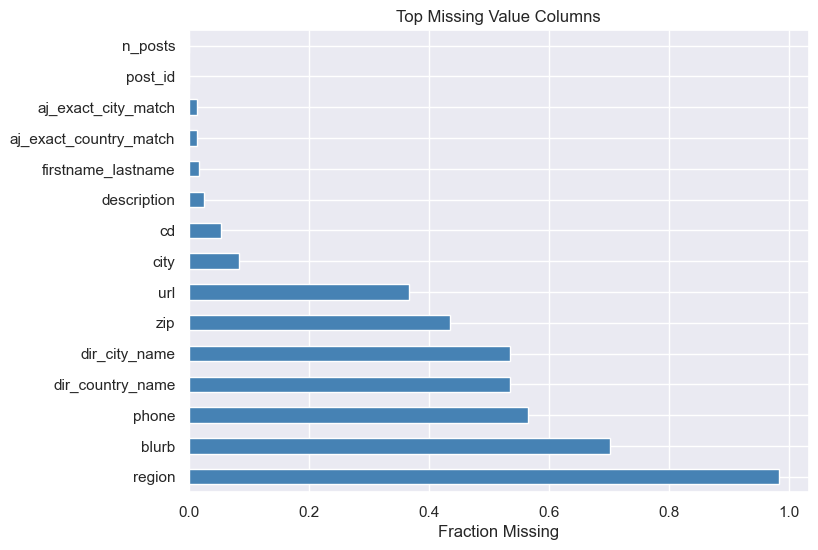

region                    0.982769
blurb                     0.701143
phone                     0.565172
dir_country_name          0.534942
dir_city_name             0.534942
zip                       0.434785
url                       0.366385
city                      0.083188
cd                        0.053699
description               0.025781
firstname_lastname        0.017536
aj_exact_country_match    0.014614
aj_exact_city_match       0.014614
post_id                   0.001483
n_posts                   0.000218
is_business_account       0.000218
lat                       0.000000
lng                       0.000000
ER                        0.000000
log_ER                    0.000000
location_id               0.000000
name                      0.000000
profile_id                0.000000
followers                 0.000000
following                 0.000000
profile_name              0.000000
number_comments           0.000000
numbr_likes               0.000000
post_type           

In [14]:
import matplotlib.pyplot as plt

missing = df.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
missing.head(15).plot(kind="barh", color="steelblue")
plt.title("Top Missing Value Columns")
plt.xlabel("Fraction Missing")
plt.show()

missing

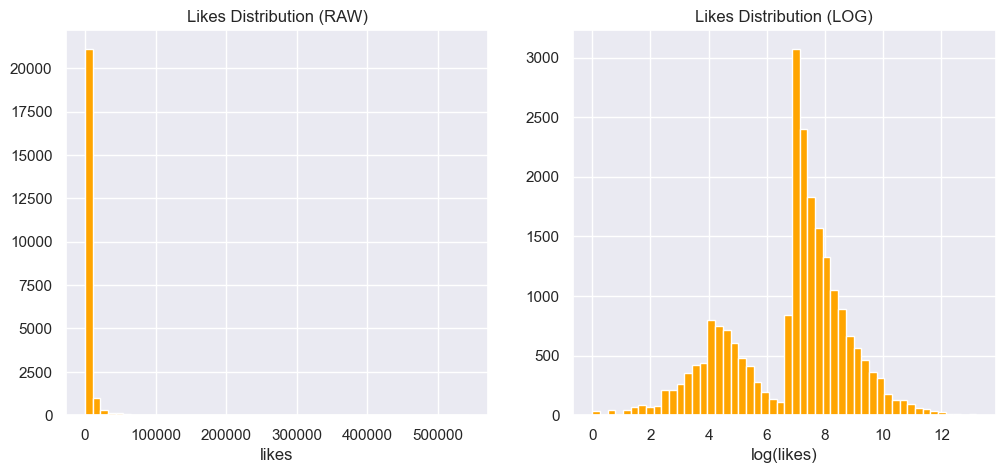

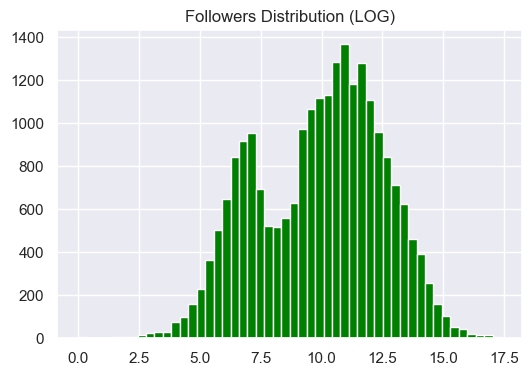

In [16]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].hist(df["numbr_likes"].dropna(), bins=50, color='orange')
axes[0].set_title("Likes Distribution (RAW)")
axes[0].set_xlabel("likes")

axes[1].hist(np.log1p(df["numbr_likes"].dropna()), bins=50, color='orange')
axes[1].set_title("Likes Distribution (LOG)")
axes[1].set_xlabel("log(likes)")

plt.show()

plt.figure(figsize=(6,4))
plt.hist(np.log1p(df["followers"]), bins=50, color="green")
plt.title("Followers Distribution (LOG)")
plt.show()


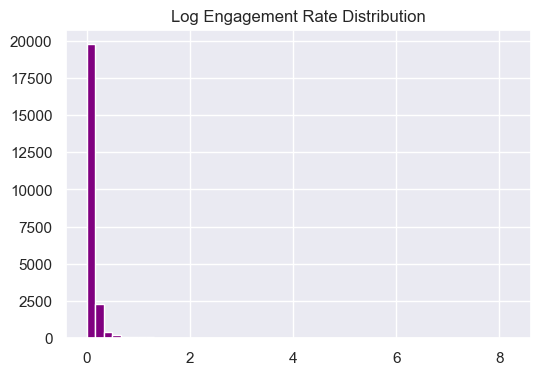

In [17]:
df["ER"] = df["numbr_likes"] / (df["followers"] + 1)
df["logER"] = np.log1p(df["ER"])

plt.figure(figsize=(6,4))
plt.hist(df["logER"], bins=50, color="purple")
plt.title("Log Engagement Rate Distribution")
plt.show()

/var/folders/12/zfkj_y912yx094_b5wlc58040000gp/T/ipykernel_60057/83932840.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="viral_label", y="logER", palette="Set2")


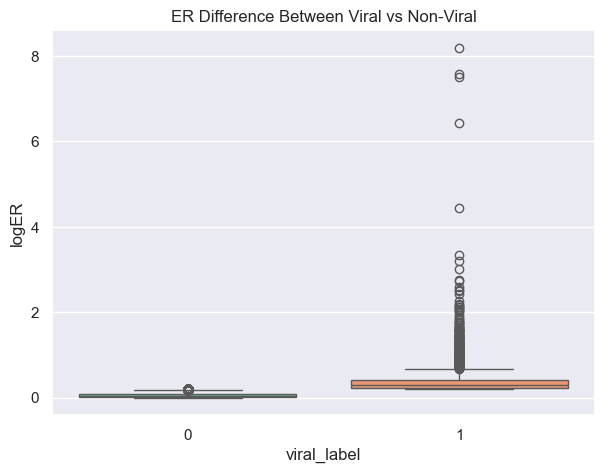

In [18]:
# creating viral_label for EDA (same as model)
thr = df["logER"].quantile(0.90)
df["viral_label"] = (df["logER"] >= thr).astype(int)

import seaborn as sns

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="viral_label", y="logER", palette="Set2")
plt.title("ER Difference Between Viral vs Non-Viral")
plt.show()

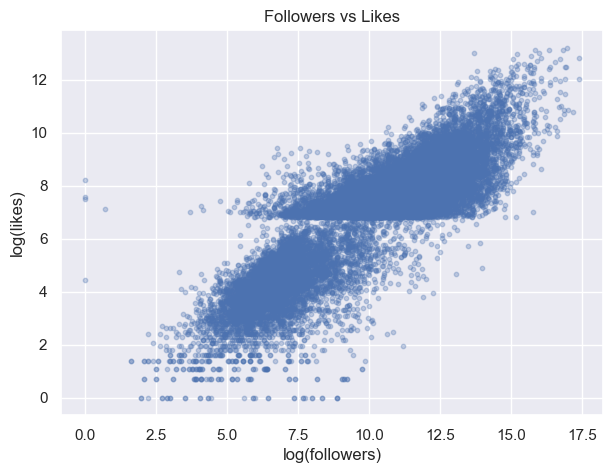

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(
    np.log1p(df["followers"]), 
    np.log1p(df["numbr_likes"]), 
    alpha=0.3, s=10
)
plt.xlabel("log(followers)")
plt.ylabel("log(likes)")
plt.title("Followers vs Likes")
plt.show()

In [20]:
viral_rate_by_type = df.groupby("post_type")["viral_label"].mean().sort_values(ascending=False)
viral_rate_by_type

post_type
1    0.101760
2    0.040248
Name: viral_label, dtype: float64

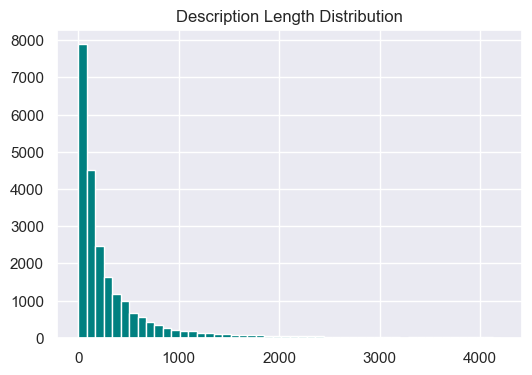

In [21]:
df["desc_len"] = df["description"].fillna("").apply(len)

plt.figure(figsize=(6,4))
plt.hist(df["desc_len"], bins=50, color="teal")
plt.title("Description Length Distribution")
plt.show()

/var/folders/12/zfkj_y912yx094_b5wlc58040000gp/T/ipykernel_60057/354590520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="viral_label", y="hashtag_count", palette="Set2")


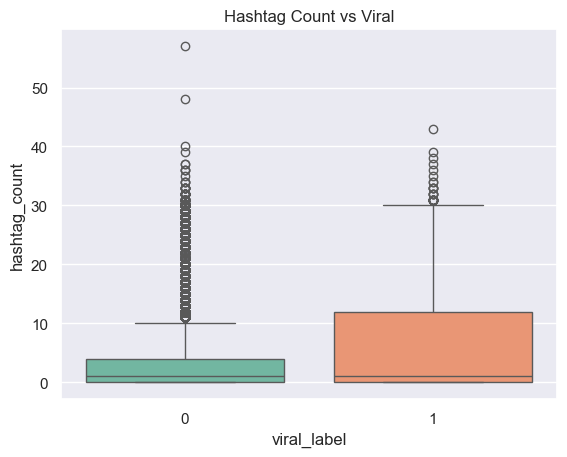

In [24]:
df["hashtag_count"] = df["description"].fillna("").apply(lambda x: x.count("#"))

sns.boxplot(data=df, x="viral_label", y="hashtag_count", palette="Set2")
plt.title("Hashtag Count vs Viral")
plt.show()

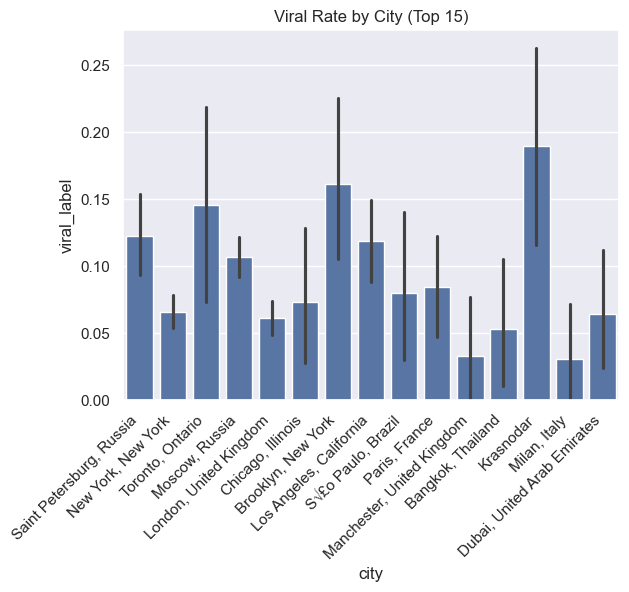

In [22]:
top_cities = df["city"].value_counts().head(15).index.tolist()
tmp = df[df["city"].isin(top_cities)]

sns.barplot(data=tmp, x="city", y="viral_label")
plt.xticks(rotation=45, ha='right')
plt.title("Viral Rate by City (Top 15)")
plt.show()

In [25]:
num_cols = ["followers", "following", "n_posts", "numbr_likes", "number_comments", "desc_len", "hashtag_count"]

sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: '2019-08-17 19:53:49.795000'